In [33]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from matplotlib import rcParams
import pandas as pd
import seaborn as sns
matplotlib_font_size=7
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Helvetica']
rcParams['font.size'] = matplotlib_font_size


path_figures=Path().cwd().parent.parent/"figures"
path_figures.mkdir(parents=True, exist_ok=True)
path_benchmark_data=Path.cwd().parent.parent/"benchmark_search_performance"
path_benchmark_data.mkdir(parents=True, exist_ok=True)

In [34]:
steps=[
    "open_search", 
    "neutral_loss_search",
    "hybrid_search"
    ]
library_size=1_000_000
query_size=100
ion_mode=[-1,1]


In [35]:
df=[]
for charge in ion_mode:
    for i in range(query_size):
        data={"total_library_number":library_size, "query_idx":i, "charge":charge}
        
        for step in steps:       
            
            
            path_benchmark_dynamic_fast_update=path_benchmark_data/f"dynamic_fast_update_{charge}_{library_size}_memory_usage_{step}_step_query_{i}.txt"
            path_benchmark_dynamic_convert_to_flash=path_benchmark_data/f"dynamic_convert_to_flash_{charge}_{library_size}_memory_usage_{step}_step_query_{i}.txt"
            path_benchmark_flash=path_benchmark_data/f"flash_{charge}_{library_size}_memory_usage_{step}_step_query_{i}.txt"

            try:
                path_benchmark_masstplus=path_benchmark_data/f"masstplus_{charge}_{library_size}_memory_usage_{step}_step_query_{i}.txt"
                with open(path_benchmark_masstplus,"r") as f:    
                    for line in f.readlines():
                        items=line.split(":", maxsplit=1)
                        key, value=items
                        if key.strip()=="Maximum resident set size (kbytes)":
                            masstplus=int(value.strip())
                data["masstplus"]=masstplus/1048576
            except:
                data["masstplus"]=None
 

            with open(path_benchmark_dynamic_fast_update,"r") as f:
                for line in f.readlines():
                    items=line.split(":", maxsplit=1)
                    key, value=items
                    if key.strip()=="Maximum resident set size (kbytes)":
                        dynamic_fast_update=int(value.strip())


            with open(path_benchmark_dynamic_convert_to_flash,"r") as f:
                for line in f.readlines():
                    items=line.split(":", maxsplit=1)
                    key, value=items
                    if key.strip()=="Maximum resident set size (kbytes)":
                        dynamic_convert_to_flash=int(value.strip())


            with open(path_benchmark_flash,"r") as f:    
                for line in f.readlines():
                    items=line.split(":", maxsplit=1)
                    key, value=items
                    if key.strip()=="Maximum resident set size (kbytes)":
                        flash=int(value.strip())


            # data["dynamic_entropy_search(fast_search)"]=dynamic_fast_search/1048576
            data["dynamic_entropy_search(fast_update)"]=dynamic_fast_update/1048576
            data["dynamic_entropy_search(convert_to_flash)"]=dynamic_convert_to_flash/1048576
            data["flash_entropy_search"]=flash/1048576
            data["search_type"]=step 


            df.append(pd.DataFrame([data]))
            
df=pd.concat(df)

df


,total_library_number,query_idx,charge,masstplus,dynamic_entropy_search(fast_update),dynamic_entropy_search(convert_to_flash),flash_entropy_search,search_type
0,1000000,0,-1,None,0.046234,0.049633,0.046642,open_search
0,1000000,0,-1,None,0.050751,0.053413,0.050053,neutral_loss_search
0,1000000,0,-1,0.210148,0.063885,0.068565,0.068951,hybrid_search
0,1000000,1,-1,None,0.039024,0.046528,0.043312,open_search
0,1000000,1,-1,None,0.046043,0.051739,0.049732,neutral_loss_search
...,...,...,...,...,...,...,...,...
0,1000000,98,1,None,0.061230,0.094570,0.090981,neutral_loss_search
0,1000000,98,1,0.440563,0.105904,0.170181,0.168594,hybrid_search
0,1000000,99,1,None,0.038403,0.043892,0.038769,open_search
0,1000000,99,1,None,0.039425,0.044189,0.039864,neutral_loss_search


In [36]:

df_data = df[["search_type", 
              "charge",
            "dynamic_entropy_search(fast_update)",
            # "dynamic_entropy_search(convert_to_flash)", 
            "flash_entropy_search",
            "masstplus"
            ]]
    
df_melted=df_data.melt(id_vars=["charge", "search_type"], var_name="method", value_name="memory_usage")
df_melted        
        


,charge,search_type,method,memory_usage
0,-1,open_search,dynamic_entropy_search(fast_update),0.046234
1,-1,neutral_loss_search,dynamic_entropy_search(fast_update),0.050751
2,-1,hybrid_search,dynamic_entropy_search(fast_update),0.063885
3,-1,open_search,dynamic_entropy_search(fast_update),0.039024
4,-1,neutral_loss_search,dynamic_entropy_search(fast_update),0.046043
...,...,...,...,...
1795,1,neutral_loss_search,masstplus,None
1796,1,hybrid_search,masstplus,0.440563
1797,1,open_search,masstplus,None
1798,1,neutral_loss_search,masstplus,None


In [37]:
my_color_palette = sns.color_palette("Set3", 12)

color_palette={
    
    "dynamic_entropy_search(fast_update)": my_color_palette[4],
    "dynamic_entropy_search(convert_to_flash)": my_color_palette[6],
    "flash_entropy_search":my_color_palette[3],
    "masstplus":my_color_palette[-3]

}

In [38]:
def plot_memory_different_search_1M(
    charge,
    df_melted,
    color_palette,
    ylim,
    save_path
):
    df_charge=df_melted[df_melted["charge"]==charge]
    hue_order=["dynamic_entropy_search(fast_update)", 
            #    "dynamic_entropy_search(convert_to_flash)", 
               "flash_entropy_search", "masstplus"]
    legend_labels = {
    "dynamic_entropy_search(fast_update)": "Dynamic Entropy Search", 
    # "dynamic_entropy_search(convert_to_flash)": "Dynamic Entropy Search (with index converted)",
    "flash_entropy_search": "Flash Entropy Search",
    "masstplus": "MASST+"
    }
    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(3, 2.4), width_ratios=[1,1,1], sharex=False, sharey=True)
    if charge==-1:
        mode="-"
    elif charge==1:
        mode="+"        
    for i, search in enumerate(["open_search", "neutral_loss_search", "hybrid_search"]):
        df_plot=df_charge[df_charge["search_type"]==search]
        ax=axes[i]
        ax.grid(True, which="both", axis="y", ls="-", alpha=0.5, linewidth=0.4)
        ax.set_title(search.replace("_"," ").title(), fontsize=matplotlib_font_size)

        sns.stripplot(x="method", y="memory_usage", hue="method", data=df_plot, hue_order=hue_order, palette=color_palette, dodge=False, jitter=0.25, size=1, alpha=0.5, linewidth=0, ax=ax)        
                
        sns.boxplot(x="method", y="memory_usage", hue="method", data=df_plot, hue_order=hue_order, dodge=False, palette=color_palette, linewidth=0.4, width=0.6, ax=ax, fliersize=0)
        
        ax.tick_params(which="both", width=0.4)          
        for spine in ax.spines.values():  
            spine.set_linewidth(0.4)

        ax.legend().remove()
        bottom=ylim[0]
        top=ylim[1]
        ax.set_ylim(bottom=bottom, top=top)
        # ax.set_yscale("log")
        ax.set_ylabel("Library Search Memory Usage (GB)")
        ax.set_xlabel("")
        ax.set_xticklabels([])
        ax.set_xticks([])

    handles = []
    for method in hue_order:
        handle = plt.Line2D([0], [0], marker='o', color=color_palette[method], 
                        markersize=3, linestyle='',label=legend_labels.get(method, method))
        handles.append(handle)

    fig.legend(handles=handles, 
            loc='upper center', 
            bbox_to_anchor=(0.5, 1.2), 
            ncol=4, 
            fontsize=matplotlib_font_size,
            frameon=False)

    fig.text(0.55, 0.2, f'({mode}) ESI', 
            ha='center', 
            fontsize=matplotlib_font_size,
            )
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.3)

    # Save figure
    plt.savefig(save_path, bbox_inches="tight", pad_inches=0.1, dpi=1200)    

/tmp/ipykernel_28266/111190815.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().remove()
/tmp/ipykernel_28266/111190815.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().remove()
/tmp/ipykernel_28266/111190815.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().remove()


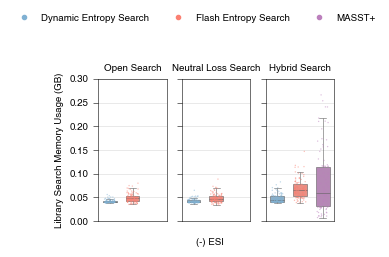

In [39]:
charge=-1
ylim=(0,0.3)
save_path=path_figures / f"memory_usage_different_search_methods_charge_{charge}_lib_scale_1M_3_methods.svg"
plot_memory_different_search_1M(
    charge=charge,
    df_melted=df_melted,
    color_palette=color_palette,
    ylim=ylim,
    save_path=save_path
)

/tmp/ipykernel_28266/111190815.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().remove()
/tmp/ipykernel_28266/111190815.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().remove()
/tmp/ipykernel_28266/111190815.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().remove()


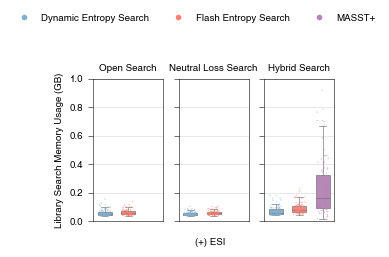

In [40]:
charge=1
ylim=(0,1)
save_path=path_figures / f"memory_usage_different_search_methods_charge_{charge}_lib_scale_1M_3_methods.svg"
plot_memory_different_search_1M(
    charge=charge,
    df_melted=df_melted,
    color_palette=color_palette,
    ylim=ylim,
    save_path=save_path
)